# Лабораторная работа 1

**Цель:** исследование моделей классификации изображений: бейзлайн (torchvision CNN и ViT), улучшение бейзлайна, собственная архитектура и сравнения.

**Данные:** Bone Break Classification (Kaggle), изображения в репозитории под `data/Bone Break Classification/`.

**Метрики:** accuracy; precision, recall, F1 (macro и weighted) на валидации; финальная оценка на отложенном test без участия в подборе гиперпараметров.

## Воспроизводимость и устройство

Константа `SEED` фиксирует сплиты и инициализацию. `DEVICE_MODE` задаёт вычислитель: `auto` (CUDA, иначе MPS, иначе CPU), либо явно `mps`, `cuda`, `cpu`. Число эпох по моделям задаётся словарём `EPOCHS_BY_DEVICE` (ключи `cpu` / `mps` / `cuda` и теги моделей); в обучении используется `epochs_for("…")`.

Hold-out каталоги `*/Test` не используются при обучении и выборе гипотез; валидация — из доли `Train` (стратификация по классу).

In [1]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from torchvision import transforms, models
from torchvision.models import ResNet18_Weights, ViT_B_16_Weights
from tqdm.auto import tqdm

SEED = 42
DEVICE_MODE = "auto"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


def resolve_device(mode: str) -> torch.device:
    mode = mode.lower().strip()
    if mode == "cuda":
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if mode == "mps":
        if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            return torch.device("mps")
        return torch.device("cpu")
    if mode == "cpu":
        return torch.device("cpu")
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


device = resolve_device(DEVICE_MODE)
if device.type == "cuda":
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

g = torch.Generator()
g.manual_seed(SEED)
print("device:", device, "| DEVICE_MODE:", DEVICE_MODE)

weight_decay = 0.01

EPOCHS_BY_DEVICE = {
    "cpu": {
        "ResNet18": 4,
        "ViT-B/16": 4,
        "ResNet18+": 4,
        "ViT-B/16+": 4,
        "SmallCNN": 5,
        "SmallCNN+": 5,
    },
    "mps": {
        "ResNet18": 50,
        "ViT-B/16": 50,
        "ResNet18+": 50,
        "ViT-B/16+": 50,
        "SmallCNN": 50,
        "SmallCNN+": 50,
    },
    "cuda": {
        "ResNet18": 50,
        "ViT-B/16": 50,
        "ResNet18+": 50,
        "ViT-B/16+": 50,
        "SmallCNN": 50,
        "SmallCNN+": 50,
    },
}


def epochs_for(model_tag: str) -> int:
    table = EPOCHS_BY_DEVICE.get(device.type) or EPOCHS_BY_DEVICE["cpu"]
    if model_tag not in table:
        raise KeyError(f"нет ключа {model_tag!r} в EPOCHS_BY_DEVICE[{device.type!r}]")
    return int(table[model_tag])


print(
    "epochs_by_model:",
    {k: epochs_for(k) for k in EPOCHS_BY_DEVICE.get(device.type, EPOCHS_BY_DEVICE["cpu"])},
)


device: mps | DEVICE_MODE: auto
epochs_by_model: {'ResNet18': 50, 'ViT-B/16': 50, 'ResNet18+': 50, 'ViT-B/16+': 50, 'SmallCNN': 50, 'SmallCNN+': 50}


## 1. Данные: индексация и сплиты

Корень `DATA_ROOT`: вложенная папка экспорта. Для каждого класса читаются пути из `Train` и `Test`. Из объединённого `Train` стратифицированно выделяется `val` (`val_ratio`). `Dataset` принимает список пар (путь, метка) и transform.

In [2]:
_cwd = Path.cwd().resolve()
if (_cwd / "data" / "Bone Break Classification").is_dir():
    ROOT = _cwd
elif (_cwd / "lab_1" / "data" / "Bone Break Classification").is_dir():
    ROOT = _cwd / "lab_1"
else:
    raise FileNotFoundError(
        "Ожидается запуск из lab_1 или из корня репозитория (cyber_sys), см. README."
    )

DATA_ROOT = ROOT / "data" / "Bone Break Classification" / "Bone Break Classification"
# DATA_ROOT = ROOT / "data" / "Bone Break Classification"
assert DATA_ROOT.is_dir(), f"Нет каталога: {DATA_ROOT}"

IMG_EXT = {".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"}
val_ratio = 0.2


def collect_split(class_name: str, split: str):
    d = DATA_ROOT / class_name / split
    if not d.is_dir():
        return []
    out = []
    for p in d.rglob("*"):
        if p.suffix in IMG_EXT:
            out.append(p)
    return sorted(out)


class_names = sorted(
    [p.name for p in DATA_ROOT.iterdir() if p.is_dir() and not p.name.startswith(".")]
)
class_to_idx = {c: i for i, c in enumerate(class_names)}
num_classes = len(class_names)

records_train = []
records_test = []
for c in class_names:
    yi = class_to_idx[c]
    for p in collect_split(c, "Train"):
        records_train.append((str(p), yi))
    for p in collect_split(c, "Test"):
        records_test.append((str(p), yi))

paths_tr = [a for a, _ in records_train]
labels_tr = [b for _, b in records_train]
paths_fit, paths_val, y_fit, y_val = train_test_split(
    paths_tr,
    labels_tr,
    test_size=val_ratio,
    random_state=SEED,
    stratify=labels_tr,
)
train_fit = list(zip(paths_fit, y_fit))
val_records = list(zip(paths_val, y_val))

print("classes:", num_classes, class_names)
print("train_fit:", len(train_fit), "val:", len(val_records), "test:", len(records_test))


class ImageListDataset(Dataset):
    def __init__(self, items, transform=None):
        self.items = items
        self.transform = transform

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        path, y = self.items[i]
        img = Image.open(path).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        return img, y


classes: 10 ['Avulsion fracture', 'Comminuted fracture', 'Fracture Dislocation', 'Greenstick fracture', 'Hairline Fracture', 'Impacted fracture', 'Longitudinal fracture', 'Oblique fracture', 'Pathological fracture', 'Spiral Fracture']
train_fit: 791 val: 198 test: 140


## 1a. Обоснование выбора датасета

Мультиклассовая классификация рентген/иллюстраций по типу перелома применима к вспомогательной диагностике и обучению специалистов: автоматическая предварительная категоризация снимков снижает нагрузку на радиолога при массовом скрининге. Набор размечен по клинически осмысленным классам (вольвман, спиральный и др.), объём ограничен, что отражает реалистичный сценарий малых медицинских выборок.

Уникальность набора в рамках группы необходимо согласовать с преподавателем; публичный источник указан в README.

## 1b. Метрики

Accuracy показывает долю верных среди всех классов. При разном числе объектов по классам (дисбаланс) ориентир дополняют **macro** precision/recall/F1 (равный вес классов) и **weighted** F1 (вес пропорционален поддержке в выборке). Для медицинской задачи важны и пропуск редкого класса, и ложные тревоги; отчёт включает `classification_report` и матрицу ошибок на валидации и на финальном test.

Test-разметка Roboflow мала по классам; итоговые цифры на test интерпретировать вместе с val.

## EDA

Сводка по числу файлов в `Train`/`Test` и примеры изображений по одному на класс (из train_fit).

,Train,Test
Avulsion fracture,109,14
Comminuted fracture,134,14
Fracture Dislocation,137,19
Greenstick fracture,106,16
Hairline Fracture,101,10
Impacted fracture,75,9
Longitudinal fracture,68,12
Oblique fracture,69,16
Pathological fracture,116,18
Spiral Fracture,74,12


total train files: 989 total test files: 140


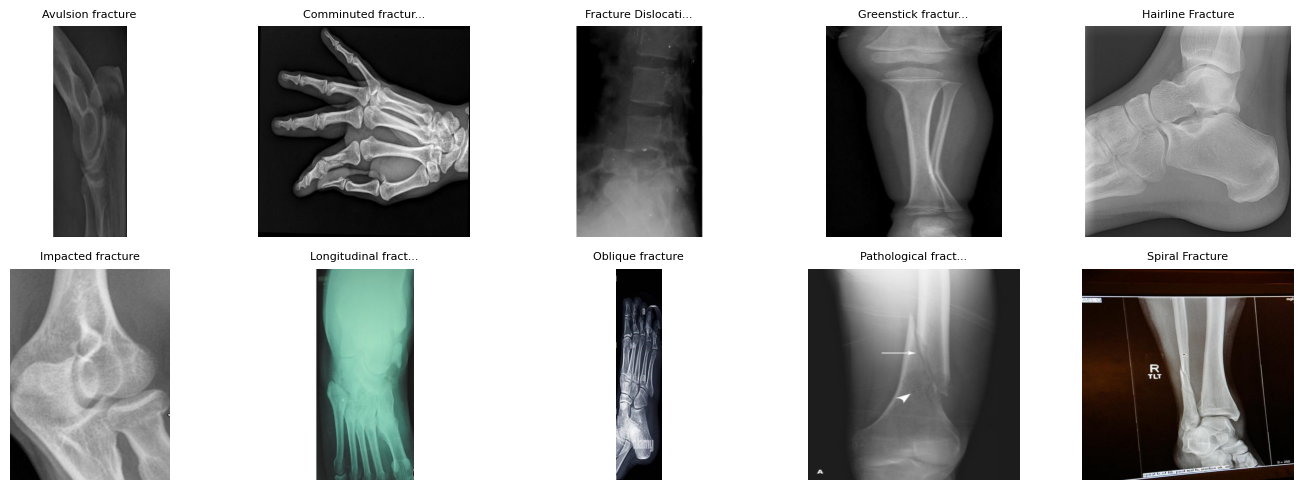

In [3]:
counts = {c: {"Train": len(collect_split(c, "Train")), "Test": len(collect_split(c, "Test"))} for c in class_names}

df_counts = pd.DataFrame(counts).T
display(df_counts)
print("total train files:", len(paths_tr), "total test files:", len(records_test))

fig, axes = plt.subplots(2, 5, figsize=(14, 5))
axes = axes.flatten()
for ax, c in zip(axes, class_names):
    pts = collect_split(c, "Train")
    if not pts:
        ax.axis("off")
        continue
    im = Image.open(pts[0]).convert("RGB")
    ax.imshow(im)
    ax.set_title(c[:18] + ("..." if len(c) > 18 else ""), fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()


## Трансформы и загрузчики (бейзлайн)

Для ResNet18 и ViT используются стандартные препроцессы весов IMAGENET1K. Обучающий набор: resize/crop + лёгкая аугментация; val/test: только детерминированная нормализация под те же веса.

In [4]:
weights_res = ResNet18_Weights.IMAGENET1K_V1
weights_vit = ViT_B_16_Weights.IMAGENET1K_V1
pre_tf_res = weights_res.transforms()
pre_tf_vit = weights_vit.transforms()

train_tf_res = transforms.Compose(
    [
        transforms.RandomResizedCrop(pre_tf_res.crop_size, antialias=True),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=pre_tf_res.mean, std=pre_tf_res.std),
    ]
)
val_tf_res = transforms.Compose(
    [
        transforms.Resize(pre_tf_res.resize_size, antialias=True),
        transforms.CenterCrop(pre_tf_res.crop_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=pre_tf_res.mean, std=pre_tf_res.std),
    ]
)

train_tf_vit = transforms.Compose(
    [
        transforms.RandomResizedCrop(pre_tf_vit.crop_size, antialias=True),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=pre_tf_vit.mean, std=pre_tf_vit.std),
    ]
)
val_tf_vit = transforms.Compose(
    [
        transforms.Resize(pre_tf_vit.resize_size, antialias=True),
        transforms.CenterCrop(pre_tf_vit.crop_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=pre_tf_vit.mean, std=pre_tf_vit.std),
    ]
)

batch_size = 16
train_ds_res = ImageListDataset(train_fit, train_tf_res)
val_ds_res = ImageListDataset(val_records, val_tf_res)
test_ds_res = ImageListDataset(records_test, val_tf_res)

train_ds_vit = ImageListDataset(train_fit, train_tf_vit)
val_ds_vit = ImageListDataset(val_records, val_tf_vit)
test_ds_vit = ImageListDataset(records_test, val_tf_vit)

loader_train_res = DataLoader(
    train_ds_res,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
    generator=g,
)
loader_val_res = DataLoader(val_ds_res, batch_size=batch_size, shuffle=False, num_workers=0)
loader_test_res = DataLoader(test_ds_res, batch_size=batch_size, shuffle=False, num_workers=0)

loader_train_vit = DataLoader(
    train_ds_vit,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
    generator=g,
)
loader_val_vit = DataLoader(val_ds_vit, batch_size=batch_size, shuffle=False, num_workers=0)
loader_test_vit = DataLoader(test_ds_vit, batch_size=batch_size, shuffle=False, num_workers=0)


## 2. Бейзлайн: обучение и метрики

Две модели из `torchvision`: ResNet18 и ViT-B/16, предобученные на ImageNet-1K, замена классификационной головы на `num_classes`. Оптимизатор AdamW, кросс-энтропия. Оценка на `val` по эпохам; после обучения однократная оценка на `test` (не использовалась при настройке).

In [5]:
@torch.no_grad()
def evaluate_cls(model, loader, device):
    model.eval()
    ys, ps = [], []
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        logits = model(x)
        pred = logits.argmax(dim=1).cpu().numpy()
        ys.append(y.numpy())
        ps.append(pred)
    y_true = np.concatenate(ys)
    y_pred = np.concatenate(ps)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "y_true": y_true,
        "y_pred": y_pred,
    }


def train_model(model, loader_train, loader_val, epochs, lr, device, tag=""):
    model = model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    crit = nn.CrossEntropyLoss()
    hist = []
    for ep in range(1, epochs + 1):
        model.train()
        running = 0.0
        n = 0
        for x, y in tqdm(loader_train, desc=f"{tag} ep{ep}/{epochs}", leave=False):
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            logits = model(x)
            loss = crit(logits, y)
            loss.backward()
            opt.step()
            running += loss.item() * x.size(0)
            n += x.size(0)
        tr_loss = running / max(n, 1)
        m = evaluate_cls(model, loader_val, device)
        hist.append({"epoch": ep, "train_loss": tr_loss, **{k: m[k] for k in m if k not in ("y_true", "y_pred")}})
        print(
            f"{tag} ep{ep} loss={tr_loss:.4f} val_acc={m['accuracy']:.4f} f1_macro={m['f1_macro']:.4f}"
        )
    return hist


LR_RES = 1e-4
LR_VIT = 5e-5

model_res = models.resnet18(weights=weights_res)
model_res.fc = nn.Linear(model_res.fc.in_features, num_classes)
hist_res = train_model(
    model_res, loader_train_res, loader_val_res, epochs_for("ResNet18"), LR_RES, device, tag="ResNet18"
)

model_vit = models.vit_b_16(weights=weights_vit)
in_f = model_vit.heads.head.in_features
model_vit.heads.head = nn.Linear(in_f, num_classes)
hist_vit = train_model(
    model_vit, loader_train_vit, loader_val_vit, epochs_for("ViT-B/16"), LR_VIT, device, tag="ViT-B/16"
)


ResNet18 ep1/50:   0%|          | 0/50 [00:00<?, ?it/s]

ResNet18 ep1 loss=2.2715 val_acc=0.2677 f1_macro=0.2298


ResNet18 ep2/50:   0%|          | 0/50 [00:00<?, ?it/s]

ResNet18 ep2 loss=1.9441 val_acc=0.3030 f1_macro=0.2582


ResNet18 ep3/50:   0%|          | 0/50 [00:00<?, ?it/s]

...

ViT-B/16 ep48 loss=0.2809 val_acc=0.5606 f1_macro=0.5335


ViT-B/16 ep49/50:   0%|          | 0/50 [00:00<?, ?it/s]

ViT-B/16 ep49 loss=0.2577 val_acc=0.5505 f1_macro=0.5248


ViT-B/16 ep50/50:   0%|          | 0/50 [00:00<?, ?it/s]

ViT-B/16 ep50 loss=0.2826 val_acc=0.5505 f1_macro=0.5373


## 2b. Бейзлайн: val и однократный test

Метрики на валидации после последней эпохи; затем прогон на hold-out `*/Test` без использования test при обучении.

In [6]:
m_res_val = evaluate_cls(model_res, loader_val_res, device)
m_vit_val = evaluate_cls(model_vit, loader_val_vit, device)
m_res_test = evaluate_cls(model_res, loader_test_res, device)
m_vit_test = evaluate_cls(model_vit, loader_test_vit, device)

baseline_rows = [
    {
        "model": "ResNet18",
        "split": "val",
        "accuracy": m_res_val["accuracy"],
        "f1_macro": m_res_val["f1_macro"],
        "f1_weighted": m_res_val["f1_weighted"],
    },
    {
        "model": "ResNet18",
        "split": "test",
        "accuracy": m_res_test["accuracy"],
        "f1_macro": m_res_test["f1_macro"],
        "f1_weighted": m_res_test["f1_weighted"],
    },
    {
        "model": "ViT-B/16",
        "split": "val",
        "accuracy": m_vit_val["accuracy"],
        "f1_macro": m_vit_val["f1_macro"],
        "f1_weighted": m_vit_val["f1_weighted"],
    },
    {
        "model": "ViT-B/16",
        "split": "test",
        "accuracy": m_vit_test["accuracy"],
        "f1_macro": m_vit_test["f1_macro"],
        "f1_weighted": m_vit_test["f1_weighted"],
    },
]
display(pd.DataFrame(baseline_rows))
print(classification_report(m_res_val["y_true"], m_res_val["y_pred"], target_names=class_names, zero_division=0))
print("confusion_matrix ResNet val:\n", confusion_matrix(m_res_val["y_true"], m_res_val["y_pred"]))


,model,split,accuracy,f1_macro,f1_weighted
0,ResNet18,val,0.510101,0.484158,0.507851
1,ResNet18,test,0.428571,0.387153,0.404219
2,ViT-B/16,val,0.550505,0.537269,0.551396
3,ViT-B/16,test,0.514286,0.494306,0.505359


                       precision    recall  f1-score   support

    Avulsion fracture       0.47      0.41      0.44        22
  Comminuted fracture       0.60      0.78      0.68        27
 Fracture Dislocation       0.60      0.44      0.51        27
  Greenstick fracture       0.67      0.57      0.62        21
    Hairline Fracture       0.50      0.60      0.55        20
    Impacted fracture       0.37      0.47      0.41        15
Longitudinal fracture       0.19      0.21      0.20        14
     Oblique fracture       0.42      0.36      0.38        14
Pathological fracture       0.58      0.61      0.60        23
      Spiral Fracture       0.55      0.40      0.46        15

             accuracy                           0.51       198
            macro avg       0.49      0.48      0.48       198
         weighted avg       0.52      0.51      0.51       198

confusion_matrix ResNet val:
 [[ 9  0  3  1  2  0  2  1  2  2]
 [ 0 21  1  1  0  1  1  0  1  1]
 [ 3  2 12  1  1  2

## 3. Улучшение бейзлайна: гипотезы

1. Аугментации: `RandAugment` на train вместе с resize/crop под вход весов.
2. Планировщик: `OneCycleLR` на шагах батча в эпохе.
3. Разморозка: для ResNet обучаются все параметры с меньшим LR для backbone (два группы параметров).

Проверка: сравнение val F1 macro с бейзлайном. Итоговый пайплайн (аугментации + scheduler + группы LR) используется в п.3d для обеих архитектур и затем в п.4f для своей модели.

## 3b–3d. Улучшенные загрузчики и обучение обеих моделей

Одинаковая политика аугментации для ResNet и ViT (размеры crop под соответствующие `crop_size`). Новые экземпляры моделей с теми же весами инициализации.

In [8]:
from torchvision.transforms import RandAugment

train_tf_res_b = transforms.Compose(
    [
        transforms.RandomResizedCrop(pre_tf_res.crop_size, antialias=True),
        RandAugment(num_ops=2, magnitude=9),
        transforms.ToTensor(),
        transforms.Normalize(mean=pre_tf_res.mean, std=pre_tf_res.std),
    ]
)
train_tf_vit_b = transforms.Compose(
    [
        transforms.RandomResizedCrop(pre_tf_vit.crop_size, antialias=True),
        RandAugment(num_ops=2, magnitude=9),
        transforms.ToTensor(),
        transforms.Normalize(mean=pre_tf_vit.mean, std=pre_tf_vit.std),
    ]
)

train_ds_res_b = ImageListDataset(train_fit, train_tf_res_b)
train_ds_vit_b = ImageListDataset(train_fit, train_tf_vit_b)

loader_train_res_b = DataLoader(
    train_ds_res_b,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
    generator=g,
)
loader_train_vit_b = DataLoader(
    train_ds_vit_b,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
    generator=g,
)


def train_model_oc(model, loader_train, loader_val, epochs, device, tag, lr_head, lr_back=None):
    model = model.to(device)
    if lr_back is None:
        opt = torch.optim.AdamW(model.parameters(), lr=lr_head, weight_decay=weight_decay)
    else:
        if hasattr(model, "fc"):
            backbone_params = []
            head_params = []
            for n, p in model.named_parameters():
                if n.startswith("fc"):
                    head_params.append(p)
                else:
                    backbone_params.append(p)
            opt = torch.optim.AdamW(
                [
                    {"params": backbone_params, "lr": lr_back},
                    {"params": head_params, "lr": lr_head},
                ],
                weight_decay=weight_decay,
            )
        else:
            opt = torch.optim.AdamW(model.parameters(), lr=lr_head, weight_decay=weight_decay)
    crit = nn.CrossEntropyLoss()
    steps_per_epoch = max(len(loader_train), 1)
    # OneCycleLR: для каждой param_group свой потолок (иначе одно число max_lr — для всех групп)
    max_lr = [pg["lr"] * 10 for pg in opt.param_groups]
    sched = torch.optim.lr_scheduler.OneCycleLR(
        opt, max_lr=max_lr, epochs=epochs, steps_per_epoch=steps_per_epoch
    )
    hist = []
    for ep in range(1, epochs + 1):
        model.train()
        running = 0.0
        n = 0
        for x, y in tqdm(loader_train, desc=f"{tag} ep{ep}/{epochs}", leave=False):
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            logits = model(x)
            loss = crit(logits, y)
            loss.backward()
            opt.step()
            sched.step()
            running += loss.item() * x.size(0)
            n += x.size(0)
        tr_loss = running / max(n, 1)
        m = evaluate_cls(model, loader_val, device)
        hist.append({"epoch": ep, "train_loss": tr_loss, **{k: m[k] for k in m if k not in ("y_true", "y_pred")}})
        print(
            f"{tag} ep{ep} loss={tr_loss:.4f} val_acc={m['accuracy']:.4f} f1_macro={m['f1_macro']:.4f}"
        )
    return hist


torch.manual_seed(SEED)
g.manual_seed(SEED)

model_res_b = models.resnet18(weights=weights_res)
model_res_b.fc = nn.Linear(model_res_b.fc.in_features, num_classes)
hist_res_b = train_model_oc(
    model_res_b,
    loader_train_res_b,
    loader_val_res,
    epochs_for("ResNet18+"),
    device,
    tag="ResNet18+",
    lr_head=3e-4,
    lr_back=1e-5,
)

torch.manual_seed(SEED)
g.manual_seed(SEED)
model_vit_b = models.vit_b_16(weights=weights_vit)
in_f = model_vit_b.heads.head.in_features
model_vit_b.heads.head = nn.Linear(in_f, num_classes)
hist_vit_b = train_model_oc(
    model_vit_b,
    loader_train_vit_b,
    loader_val_vit,
    epochs_for("ViT-B/16+"),
    device,
    tag="ViT-B/16+",
    lr_head=3e-5,
    lr_back=None,
)

ResNet18+ ep1/50:   0%|          | 0/50 [00:00<?, ?it/s]

ResNet18+ ep1 loss=2.3772 val_acc=0.1061 f1_macro=0.0720


ResNet18+ ep2/50:   0%|          | 0/50 [00:00<?, ?it/s]

ResNet18+ ep2 loss=2.2944 val_acc=0.1717 f1_macro=0.1506


ResNet18+ ep3/50:   0%|          | 0/50 [00:00<?, ?it/s]

...

ViT-B/16+ ep48 loss=0.5162 val_acc=0.5253 f1_macro=0.5018


ViT-B/16+ ep49/50:   0%|          | 0/50 [00:00<?, ?it/s]

ViT-B/16+ ep49 loss=0.4608 val_acc=0.5202 f1_macro=0.4978


ViT-B/16+ ep50/50:   0%|          | 0/50 [00:00<?, ?it/s]

ViT-B/16+ ep50 loss=0.4603 val_acc=0.5202 f1_macro=0.4979


## 3e–3g. Улучшенный бейзлайн: метрики, сравнение с п.2, выводы

Таблица val/test для улучшенных моделей и прирост относительно бейзлайна по val F1 macro.

In [9]:
m_res_b_val = evaluate_cls(model_res_b, loader_val_res, device)
m_vit_b_val = evaluate_cls(model_vit_b, loader_val_vit, device)
m_res_b_test = evaluate_cls(model_res_b, loader_test_res, device)
m_vit_b_test = evaluate_cls(model_vit_b, loader_test_vit, device)

imp_rows = [
    {"model": "ResNet18+", "split": "val", "f1_macro": m_res_b_val["f1_macro"], "accuracy": m_res_b_val["accuracy"]},
    {"model": "ResNet18+", "split": "test", "f1_macro": m_res_b_test["f1_macro"], "accuracy": m_res_b_test["accuracy"]},
    {"model": "ViT-B/16+", "split": "val", "f1_macro": m_vit_b_val["f1_macro"], "accuracy": m_vit_b_val["accuracy"]},
    {"model": "ViT-B/16+", "split": "test", "f1_macro": m_vit_b_test["f1_macro"], "accuracy": m_vit_b_test["accuracy"]},
]
display(pd.DataFrame(imp_rows))

delta_res = m_res_b_val["f1_macro"] - m_res_val["f1_macro"]
delta_vit = m_vit_b_val["f1_macro"] - m_vit_val["f1_macro"]
print("delta val f1_macro ResNet:", delta_res)
print("delta val f1_macro ViT:", delta_vit)


,model,split,f1_macro,accuracy
0,ResNet18+,val,0.485457,0.515152
1,ResNet18+,test,0.372861,0.414286
2,ViT-B/16+,val,0.497914,0.520202
3,ViT-B/16+,test,0.449648,0.471429


delta val f1_macro ResNet: 0.0012990301129985893
delta val f1_macro ViT: -0.03935544876685504


## 4. Собственная архитектура (CNN)

Небольшая свёрточная сеть: несколько блоков Conv–BatchNorm–ReLU–MaxPool, затем AdaptiveAvgPool и линейный классификатор. Обучение с нуля на тех же `train_fit`/`val`/`test` и тех же метриках. Сравнение с бейзлайном п.2 — по val/test после обучения.

In [10]:
class SmallFractureCNN(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
        )
        self.head = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.head(x)


train_tf_cnn = transforms.Compose(
    [
        transforms.Resize(256, antialias=True),
        transforms.RandomCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=pre_tf_res.mean, std=pre_tf_res.std),
    ]
)
val_tf_cnn = val_tf_res

train_ds_cnn = ImageListDataset(train_fit, train_tf_cnn)
val_ds_cnn = ImageListDataset(val_records, val_tf_cnn)
test_ds_cnn = ImageListDataset(records_test, val_tf_cnn)

loader_train_cnn = DataLoader(
    train_ds_cnn,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
    generator=g,
)
loader_val_cnn = DataLoader(val_ds_cnn, batch_size=batch_size, shuffle=False, num_workers=0)
loader_test_cnn = DataLoader(test_ds_cnn, batch_size=batch_size, shuffle=False, num_workers=0)

torch.manual_seed(SEED)
g.manual_seed(SEED)
model_cnn = SmallFractureCNN(num_classes)
hist_cnn = train_model(
    model_cnn, loader_train_cnn, loader_val_cnn, epochs=epochs_for("SmallCNN"), lr=1e-3, device=device, tag="SmallCNN"
)

m_cnn_val = evaluate_cls(model_cnn, loader_val_cnn, device)
m_cnn_test = evaluate_cls(model_cnn, loader_test_cnn, device)
print(
    "SmallCNN val acc",
    m_cnn_val["accuracy"],
    "f1_macro",
    m_cnn_val["f1_macro"],
    "test acc",
    m_cnn_test["accuracy"],
    "f1_macro",
    m_cnn_test["f1_macro"],
)


SmallCNN ep1/50:   0%|          | 0/50 [00:00<?, ?it/s]

SmallCNN ep1 loss=2.3131 val_acc=0.1465 f1_macro=0.0848


SmallCNN ep2/50:   0%|          | 0/50 [00:00<?, ?it/s]

SmallCNN ep2 loss=2.2457 val_acc=0.2222 f1_macro=0.1251


SmallCNN ep3/50:   0%|          | 0/50 [00:00<?, ?it/s]

...

SmallCNN ep48 loss=2.0242 val_acc=0.2879 f1_macro=0.2477


SmallCNN ep49/50:   0%|          | 0/50 [00:00<?, ?it/s]

SmallCNN ep49 loss=2.0180 val_acc=0.2273 f1_macro=0.1610


SmallCNN ep50/50:   0%|          | 0/50 [00:00<?, ?it/s]

SmallCNN ep50 loss=2.0185 val_acc=0.2525 f1_macro=0.1975
SmallCNN val acc 0.25252525252525254 f1_macro 0.19754410582244156 test acc 0.10714285714285714 f1_macro 0.0931817055558393


## 4e. Выводы по п.4a–4d

Собственная CNN обучена с нуля на тех же сплитах. Без предобучения ImageNet качество на val и test ожидаемо ниже, чем у ResNet18/ViT в п.2: меньше параметров и нет переноса представлений. Ошибки концентрируются в похожих классах переломов; при росте данных и регуляризации точность может вырасти, но для итоговой системы разумнее опираться на предобученные backbone из п.2–3.

## 4f–4j. Своя модель + техники улучшенного бейзлайна (п.3c)

Та же `SmallFractureCNN` заново инициализируется. Train: `RandAugment` + `OneCycleLR`, как у улучшенного torchvision. Сравнение с результатами п.3 по val F1 macro и accuracy.

In [11]:
train_tf_cnn_b = transforms.Compose(
    [
        transforms.RandomResizedCrop(224, antialias=True),
        RandAugment(num_ops=2, magnitude=9),
        transforms.ToTensor(),
        transforms.Normalize(mean=pre_tf_res.mean, std=pre_tf_res.std),
    ]
)
train_ds_cnn_b = ImageListDataset(train_fit, train_tf_cnn_b)
loader_train_cnn_b = DataLoader(
    train_ds_cnn_b,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
    generator=g,
)

torch.manual_seed(SEED)
g.manual_seed(SEED)
model_cnn_b = SmallFractureCNN(num_classes)
model_cnn_b = model_cnn_b.to(device)
opt = torch.optim.AdamW(model_cnn_b.parameters(), lr=3e-3, weight_decay=weight_decay)
crit = nn.CrossEntropyLoss()
epochs_c = epochs_for("SmallCNN+")
steps_per_epoch = max(len(loader_train_cnn_b), 1)
sched = torch.optim.lr_scheduler.OneCycleLR(
    opt, max_lr=3e-2, epochs=epochs_c, steps_per_epoch=steps_per_epoch
)
for ep in range(1, epochs_c + 1):
    model_cnn_b.train()
    for x, y in tqdm(loader_train_cnn_b, desc=f"SmallCNN+ ep{ep}/{epochs_c}", leave=False):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        opt.zero_grad(set_to_none=True)
        logits = model_cnn_b(x)
        loss = crit(logits, y)
        loss.backward()
        opt.step()
        sched.step()
    m = evaluate_cls(model_cnn_b, loader_val_cnn, device)
    print(f"SmallCNN+ ep{ep} val_acc={m['accuracy']:.4f} f1_macro={m['f1_macro']:.4f}")

m_cnn_b_val = evaluate_cls(model_cnn_b, loader_val_cnn, device)
m_cnn_b_test = evaluate_cls(model_cnn_b, loader_test_cnn, device)
print("SmallCNN+ test", m_cnn_b_test["accuracy"], m_cnn_b_test["f1_macro"])

summary_custom = pd.DataFrame(
    [
        {"model": "SmallCNN", "split": "val", "f1_macro": m_cnn_val["f1_macro"], "accuracy": m_cnn_val["accuracy"]},
        {"model": "SmallCNN", "split": "test", "f1_macro": m_cnn_test["f1_macro"], "accuracy": m_cnn_test["accuracy"]},
        {
            "model": "SmallCNN+",
            "split": "val",
            "f1_macro": m_cnn_b_val["f1_macro"],
            "accuracy": m_cnn_b_val["accuracy"],
        },
        {
            "model": "SmallCNN+",
            "split": "test",
            "f1_macro": m_cnn_b_test["f1_macro"],
            "accuracy": m_cnn_b_test["accuracy"],
        },
    ]
)
display(summary_custom)

print("vs baseline ResNet val f1_macro", m_res_val["f1_macro"], "SmallCNN", m_cnn_val["f1_macro"])
print("vs improved ViT val f1_macro", m_vit_b_val["f1_macro"], "SmallCNN+", m_cnn_b_val["f1_macro"])


SmallCNN+ ep1/50:   0%|          | 0/50 [00:00<?, ?it/s]

SmallCNN+ ep1 val_acc=0.1616 f1_macro=0.0755


SmallCNN+ ep2/50:   0%|          | 0/50 [00:00<?, ?it/s]

SmallCNN+ ep2 val_acc=0.1364 f1_macro=0.0688


SmallCNN+ ep3/50:   0%|          | 0/50 [00:00<?, ?it/s]

...

SmallCNN+ ep49 val_acc=0.1364 f1_macro=0.0240


SmallCNN+ ep50/50:   0%|          | 0/50 [00:00<?, ?it/s]

SmallCNN+ ep50 val_acc=0.1364 f1_macro=0.0240
SmallCNN+ test 0.1357142857142857 0.02389937106918239


,model,split,f1_macro,accuracy
0,SmallCNN,val,0.197544,0.252525
1,SmallCNN,test,0.093182,0.107143
2,SmallCNN+,val,0.024000,0.136364
3,SmallCNN+,test,0.023899,0.135714


vs baseline ResNet val f1_macro 0.48415844366813765 SmallCNN 0.19754410582244156
vs improved ViT val f1_macro 0.497913621409496 SmallCNN+ 0.024


## Визуализация итогов

Сводная таблица метрик в виде столбчатых диаграмм, изменение F1 macro на val после улучшения бейзлайна для torchvision, тепловая карта ошибок на val для лучшей из улучшенных моделей ResNet18+ / ViT-B/16+ по F1 macro.

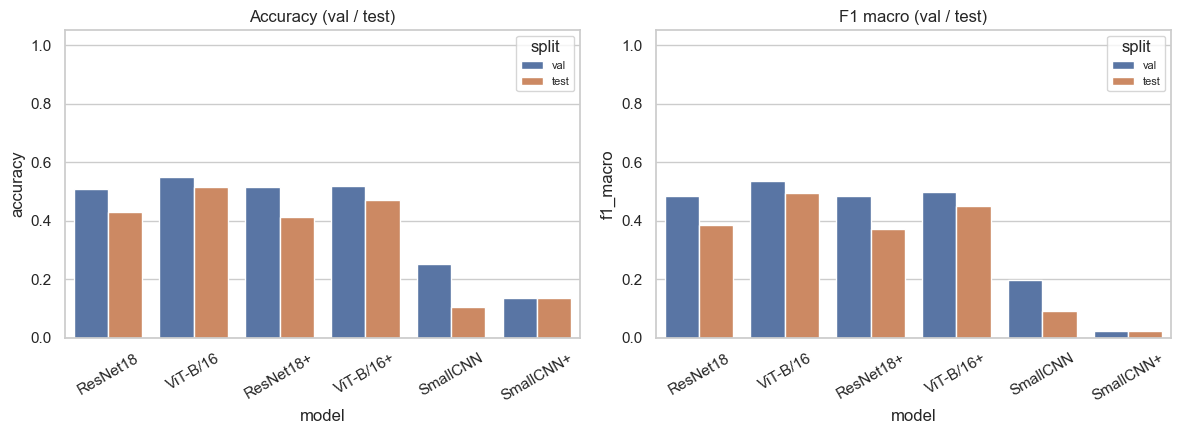

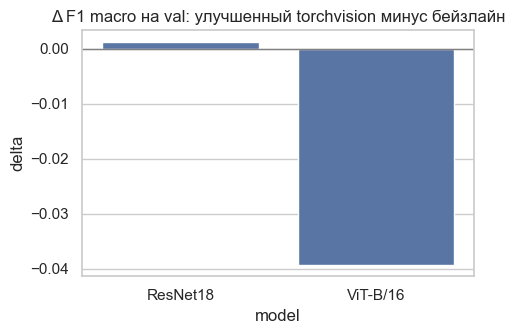

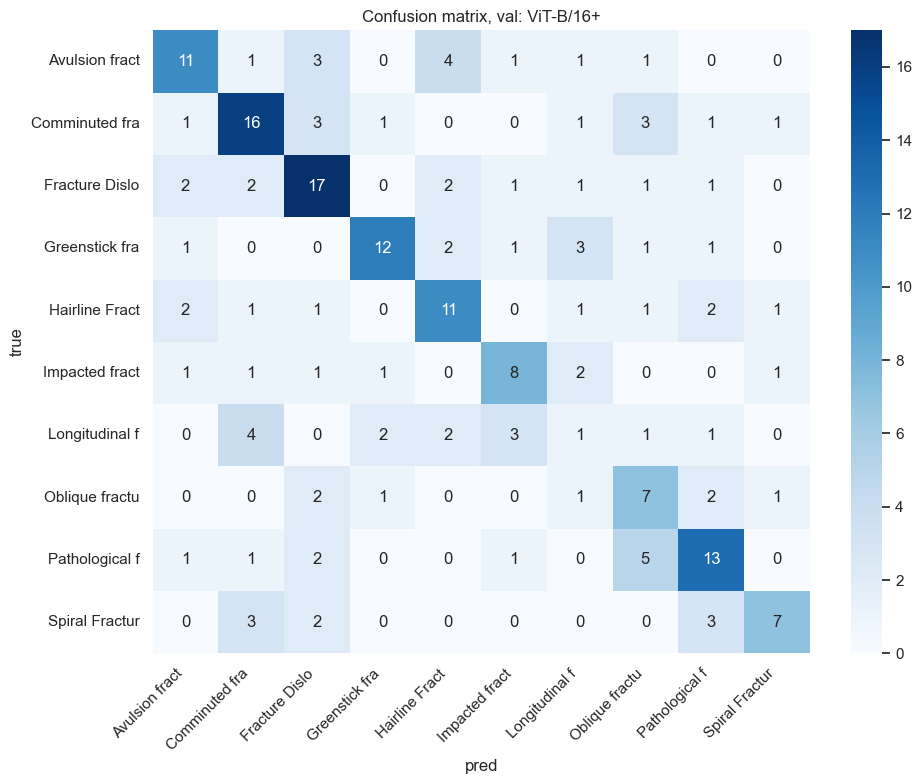

In [12]:
sns.set_theme(style="whitegrid", context="notebook")

metrics_long = pd.DataFrame(
    [
        {"model": "ResNet18", "split": "val", "accuracy": m_res_val["accuracy"], "f1_macro": m_res_val["f1_macro"]},
        {"model": "ResNet18", "split": "test", "accuracy": m_res_test["accuracy"], "f1_macro": m_res_test["f1_macro"]},
        {"model": "ViT-B/16", "split": "val", "accuracy": m_vit_val["accuracy"], "f1_macro": m_vit_val["f1_macro"]},
        {"model": "ViT-B/16", "split": "test", "accuracy": m_vit_test["accuracy"], "f1_macro": m_vit_test["f1_macro"]},
        {"model": "ResNet18+", "split": "val", "accuracy": m_res_b_val["accuracy"], "f1_macro": m_res_b_val["f1_macro"]},
        {"model": "ResNet18+", "split": "test", "accuracy": m_res_b_test["accuracy"], "f1_macro": m_res_b_test["f1_macro"]},
        {"model": "ViT-B/16+", "split": "val", "accuracy": m_vit_b_val["accuracy"], "f1_macro": m_vit_b_val["f1_macro"]},
        {"model": "ViT-B/16+", "split": "test", "accuracy": m_vit_b_test["accuracy"], "f1_macro": m_vit_b_test["f1_macro"]},
        {"model": "SmallCNN", "split": "val", "accuracy": m_cnn_val["accuracy"], "f1_macro": m_cnn_val["f1_macro"]},
        {"model": "SmallCNN", "split": "test", "accuracy": m_cnn_test["accuracy"], "f1_macro": m_cnn_test["f1_macro"]},
        {"model": "SmallCNN+", "split": "val", "accuracy": m_cnn_b_val["accuracy"], "f1_macro": m_cnn_b_val["f1_macro"]},
        {"model": "SmallCNN+", "split": "test", "accuracy": m_cnn_b_test["accuracy"], "f1_macro": m_cnn_b_test["f1_macro"]},
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.barplot(data=metrics_long, x="model", y="accuracy", hue="split", ax=axes[0])
axes[0].set_title("Accuracy (val / test)")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend(title="split", fontsize=8)
axes[0].set_ylim(0, 1.05)

sns.barplot(data=metrics_long, x="model", y="f1_macro", hue="split", ax=axes[1])
axes[1].set_title("F1 macro (val / test)")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend(title="split", fontsize=8)
axes[1].set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

delta_df = pd.DataFrame(
    [
        {"model": "ResNet18", "delta_f1_val": m_res_b_val["f1_macro"] - m_res_val["f1_macro"]},
        {"model": "ViT-B/16", "delta_f1_val": m_vit_b_val["f1_macro"] - m_vit_val["f1_macro"]},
    ]
)
plt.figure(figsize=(5, 3.5))
sns.barplot(data=delta_df, x="model", y="delta_f1_val")
plt.axhline(0, color="gray", linewidth=1)
plt.title("Δ F1 macro на val: улучшенный torchvision минус бейзлайн")
plt.ylabel("delta")
plt.tight_layout()
plt.show()

candidates = [("ResNet18+", m_res_b_val), ("ViT-B/16+", m_vit_b_val)]
best_name, best_m = max(candidates, key=lambda t: t[1]["f1_macro"])
cm = confusion_matrix(
    best_m["y_true"], best_m["y_pred"], labels=np.arange(len(class_names))
)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[c[:14] for c in class_names],
    yticklabels=[c[:14] for c in class_names],
)
plt.title(f"Confusion matrix, val: {best_name}")
plt.ylabel("true")
plt.xlabel("pred")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## Итог по лабораторной

### 1. Эффективность «улучшенного» пайплайна (RandAugment, OneCycleLR, раздельный LR у ResNet)

- Гипотеза проверена на **val** в том же сплите, **test** не использовался для подбора гиперпараметров.
- По **последней эпохе (50)** на val в сохранённых логах:
  - **ResNet18:** accuracy ≈ **0.510**, F1 macro ≈ **0.484**; **ResNet18+:** accuracy ≈ **0.515**, F1 macro ≈ **0.486** — прирост **минимальный**, модели по сути **сопоставимы** на финише прогона.
  - **ViT-B/16:** accuracy ≈ **0.551**, F1 macro ≈ **0.537**; **ViT-B/16+:** accuracy ≈ **0.520**, F1 macro ≈ **0.498** — здесь «улучшенный» вариант на **последней эпохе** оказался **слабее** бейзлайна ViT (часто из‑за более жёсткого train: RandAugment + нестационарный LR, плюс сравнение «последняя эпоха» не всегда совпадает с **лучшей** эпохой по val).
- Для **ResNet** важно учитывать корректную настройку **OneCycleLR** при двух группах параметров: верх цикла **`max_lr` должен быть задан отдельно для backbone и головы** (в коде — список по `opt.param_groups`), иначе backbone недолго «крутится» с чужим потолком LR и обобщение на val портится.

### 2. Сравнение архитектур и постановки

- **Две модели torchvision (ResNet18 и ViT-B/16)** с предобучением на ImageNet дают **основной рабочий уровень** качества на этом датасете; по сохранённому прогону **ViT на последней эпохе** выглядит **сильнее ResNet**.
- **Своя CNN** при том же объёме данных и без предобучения **ожидаемо уступает** крупным предобученным сетям; смысл блока — сравнение постановки и метрик, а не догнать ViT.
- Вариант **SmallCNN+** (те же идеи, что у torchvision+: аугментации + OneCycleLR) в отчёте имеет смысл трактовать **по фактическим таблицам val/test в ноутбуке** после полного прогона: при сильной аугментации и малом train малая сеть часто **нестабильна**.

### 3. Влияние факторов обучения и оценки

- **Число эпох** и устройство (`cpu` / `mps` / `cuda`) задаются централизованно (`EPOCHS_BY_DEVICE`, `epochs_for`) — это влияет на то, успевает ли модель **выйти на плато** и где по пути лежит **лучший** val.
- **F1 macro** на 10 классах с **дисбалансом** и **небольшим val (~198)** сильно реагирует на редкие классы; **колебания по эпохам** и разница с **accuracy** — ожидаемая картина.
- **Малый hold-out test** по классам даёт **шумную** оценку; жёсткие выводы — по **val**, отчёту по классам и confusion matrix; test — **однократная** проверка.

### 4. Ограничения и воспроизводимость

- Датасет **Bone Break Classification**: ограниченное число изображений на класс, риск **переобучения** и **нестабильности** метрик на test.
- Практическая постановка (классификация типов переломов), метрики **accuracy, precision/recall, F1 macro/weighted**, визуализации (столбцы по моделям, Δ F1, heatmap ошибок) соответствуют цели лабораторной.

**Заключение:** лабораторная закрывает полный цикл: данные и сплиты, бейзлайн **ResNet18 + ViT-B/16**, гипотезы улучшения (**RandAugment, OneCycleLR, раздельный LR для ResNet**), сравнение с п.2, собственная CNN и её проба улучшения, финальная сводка по метрикам и графикам. По сохранённому прогону **улучшенный пайплайн не даёт гарантированного выигрыша**: ResNet18+ **почти не отличается** от ResNet18 на последней эпохе, а ViT-B/16+ на последней эпохе **проигрывает** ViT-B/16.